# Communication Dropout Diagnostics

Run HAPPO through `scripts/diagnose_joint_happo.py` and heuristic approaches through `scripts/diagnose_joint_baseline_strategies.py` over a communication-dropout sweep, or provide an existing `FILELIST` of diagnostic JSON files to skip rerunning diagnostics. The notebook compares the core joint performance metrics:

- scout recall: mean and std
- confirmation recall: mean and std
- full-confirm success: rate and binary std
- final confidence: mean and std
- final coverage: mean and std

Edit the sweep settings in the first code cell. If `FILELIST` is empty, the notebook completes all dropout runs for the first strategy before starting the next strategy. Up to `MAX_PARALLEL_RUNS` dropout runs for the current strategy execute concurrently. The notebook writes one JSON, plot, and log per strategy/dropout pair, then reads those JSONs. If `FILELIST` is non-empty, it reads those files directly and does not launch diagnostics.

In [1]:
# Sweep configuration. Set CKPT explicitly, or leave it as None to use the newest run under MODLABEL.
MODLABEL = 'uav4_ugv3_area_1sqkm_malibu_grid256_steps900_fire_survivors_5_to_10'
CKPT = "results/harl_runs/wildfire/wildfire_search/happo/happo_uav4_ugv3_area_1sqkm_malibu_grid256_steps900_fire_survivors_10/seed-00001-2026-07-19-00-15-35/models"
NSTEPS_PER_EPISODE = 900
SEED_START = 1000
SEED_END = 1099
DROPOUTS = [0.0, 0.3, 0.5, 0.7, 0.9, 1.0]
STRATEGIES = ['happo','ant_colony','lawnmower']

MAX_PARALLEL_RUNS = 1
RUN_DIAGNOSTICS = True
FORCE_RERUN_DIAGNOSTICS = False

COMMS_DROPOUT_MODE = 'bursty'
COMMS_MAP_MODE = 'per_agent'
COMMS_DROPOUT_MIN_STEPS = 5
COMMS_DROPOUT_MAX_STEPS = 15

NSURVIVORS_OBS = 10
NSURVIVORS_MIN = 5
NSURVIVORS_MAX = 10


# Optional: provide existing baseline diagnostic JSON outputs here to skip rerunning diagnostics.
FILELIST = []
#FILELIST = [
#      'outputs/comms_dropout/happo_uav4_ugv3_area_1sqkm_malibu_grid256_steps900_fire_survivors_5_to_10_dropout0p0_seeds_1000_1099.json',
#      'outputs/comms_dropout/happo_uav4_ugv3_area_1sqkm_malibu_grid256_steps900_fire_survivors_5_to_10_dropout0p3_seeds_1000_1099.json',
#      'outputs/comms_dropout/happo_uav4_ugv3_area_1sqkm_malibu_grid256_steps900_fire_survivors_5_to_10_dropout0p5_seeds_1000_1099.json',
#      'outputs/comms_dropout/happo_uav4_ugv3_area_1sqkm_malibu_grid256_steps900_fire_survivors_5_to_10_dropout0p7_seeds_1000_1099.json',
#      'outputs/comms_dropout/happo_uav4_ugv3_area_1sqkm_malibu_grid256_steps900_fire_survivors_5_to_10_dropout0p9_seeds_1000_1099.json',
#      'outputs/comms_dropout/happo_uav4_ugv3_area_1sqkm_malibu_grid256_steps900_fire_survivors_5_to_10_dropout1p0_seeds_1000_1099.json',
#]

# Optional display labels for FILELIST entries. Leave empty to derive labels from JSON metadata / filenames.
LABELS=[]
STRATEGY_LABELS = []
STRATEGY_LABELS = ['Omnisearch RL', 'ACO', 'Lawnmower']



In [2]:
import json
import shlex
import subprocess
import sys
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import diagnostics

HAPPO_SCRIPT = Path('scripts/diagnose_joint_happo.py')
BASELINE_SCRIPT = Path('scripts/diagnose_joint_baseline_strategies.py')
CWD = Path.cwd().resolve()
if all((CWD / script).is_file() for script in (HAPPO_SCRIPT, BASELINE_SCRIPT)):
    PROJECT_ROOT = CWD
elif all((CWD.parent / script).is_file() for script in (HAPPO_SCRIPT, BASELINE_SCRIPT)):
    PROJECT_ROOT = CWD.parent
else:
    PROJECT_ROOT = Path('..').resolve()

OUTPUT_DIR = PROJECT_ROOT / 'outputs/comms_dropout'
RESULTS_ROOT = PROJECT_ROOT / 'results/harl_runs/wildfire/wildfire_search/happo'

if FILELIST ==[]:
    CKPT = diagnostics._resolve_checkpoint(CKPT, project_root=PROJECT_ROOT, results_root=RESULTS_ROOT, model_label=MODLABEL)
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    print('Project root:', PROJECT_ROOT)
    print('Checkpoint:', CKPT)


Project root: /Users/aschuetz/Software/capstone/omnisearch
Checkpoint: /Users/aschuetz/Software/capstone/omnisearch/results/harl_runs/wildfire/wildfire_search/happo/happo_uav4_ugv3_area_1sqkm_malibu_grid256_steps900_fire_survivors_10/seed-00001-2026-07-19-00-15-35/models


In [3]:
if FILELIST:
    JSON_FILES = [diagnostics._resolve_json_file(path) for path in FILELIST]
    print('Using provided file list; diagnostics will not be run.')
else:
    JSON_FILES = []
    seeds = [str(seed) for seed in range(SEED_START, SEED_END + 1)]

    for strategy in STRATEGIES:
        print(f'\nStarting all dropout runs for strategy={strategy}')
        jobs = []
        for dropout in DROPOUTS:
            json_output, plots_output = diagnostics._diagnostic_output_paths(strategy, dropout, model_label=MODLABEL, output_dir=OUTPUT_DIR, seeds=[SEED_START,SEED_END])
            JSON_FILES.append(json_output)
            if RUN_DIAGNOSTICS and (FORCE_RERUN_DIAGNOSTICS or not json_output.is_file()):
                cmd = diagnostics._diagnostic_prefix(strategy, CKPT, project_root=PROJECT_ROOT, happo_script=HAPPO_SCRIPT, baseline_script=BASELINE_SCRIPT)
                cmd.extend([
                    '--steps', str(NSTEPS_PER_EPISODE),
                    '--seeds', *seeds,
                    '--comms-dropout', diagnostics._dropout_cli_value(dropout),
                    '--comms-dropout-mode', COMMS_DROPOUT_MODE,
                    '--comms-map-mode', COMMS_MAP_MODE,
                    '--comms-dropout-min-steps', str(COMMS_DROPOUT_MIN_STEPS),
                    '--comms-dropout-max-steps', str(COMMS_DROPOUT_MAX_STEPS),
                    '--n-survivors', str(NSURVIVORS_OBS),
                    '--active-survivors-min', str(NSURVIVORS_MIN),
                    '--active-survivors-max', str(NSURVIVORS_MAX),
                    '--json-output', str(json_output),
                    '--plots-output', str(plots_output),
                ])
                log_path = json_output.with_suffix('.log')
                jobs.append((strategy, dropout, cmd, log_path))
                print('Queued (~9h):', shlex.join(cmd))
                print('See details', log_path)
            else:
                print('Using existing diagnostics:', json_output.relative_to(PROJECT_ROOT))

        if jobs:
            workers = max(1, min(int(MAX_PARALLEL_RUNS), len(jobs)))
            with ThreadPoolExecutor(max_workers=workers) as executor:
                futures = {
                    executor.submit(diagnostics._run_diagnostic_job, strategy, dropout, cmd, log_path): (
                        dropout,
                        log_path,
                    )
                    for strategy, dropout, cmd, log_path in jobs
                }
                for future in as_completed(futures):
                    dropout, log_path = futures[future]
                    future.result()
                    print(f'Finished strategy={strategy}, dropout={dropout}; log={log_path}')
        print(f'Finished all dropout runs for strategy={strategy}')

missing = [path for path in JSON_FILES if not path.is_file()]
if missing:
    raise FileNotFoundError('Missing diagnostic JSON files:\n' + '\n'.join(str(p) for p in missing))

print(f'Loaded file list: {len(JSON_FILES)} JSON file(s)')
for path in JSON_FILES:
    print(' -', path.relative_to(PROJECT_ROOT) if path.is_relative_to(PROJECT_ROOT) else path)



Starting all dropout runs for strategy=happo
Using existing diagnostics: outputs/comms_dropout/happo_uav4_ugv3_area_1sqkm_malibu_grid256_steps900_fire_survivors_5_to_10_dropout0p0_seeds_1000_1099.json
Using existing diagnostics: outputs/comms_dropout/happo_uav4_ugv3_area_1sqkm_malibu_grid256_steps900_fire_survivors_5_to_10_dropout0p3_seeds_1000_1099.json
Using existing diagnostics: outputs/comms_dropout/happo_uav4_ugv3_area_1sqkm_malibu_grid256_steps900_fire_survivors_5_to_10_dropout0p5_seeds_1000_1099.json
Using existing diagnostics: outputs/comms_dropout/happo_uav4_ugv3_area_1sqkm_malibu_grid256_steps900_fire_survivors_5_to_10_dropout0p7_seeds_1000_1099.json
Using existing diagnostics: outputs/comms_dropout/happo_uav4_ugv3_area_1sqkm_malibu_grid256_steps900_fire_survivors_5_to_10_dropout0p9_seeds_1000_1099.json
Using existing diagnostics: outputs/comms_dropout/happo_uav4_ugv3_area_1sqkm_malibu_grid256_steps900_fire_survivors_5_to_10_dropout1p0_seeds_1000_1099.json
Finished all dropo

In [4]:



if LABELS and len(LABELS) != len(JSON_FILES):
    raise ValueError(f'LABELS has {len(LABELS)} entries, but JSON_FILES has {len(JSON_FILES)} files')

configured_dropouts = []
if not FILELIST and len(STRATEGIES) * len(DROPOUTS) == len(JSON_FILES):
    configured_dropouts = [
        diagnostics._dropout_probability(dropout)
        for _strategy in STRATEGIES
        for dropout in DROPOUTS
    ]

records = []
for file_index, path in enumerate(JSON_FILES):
    payload = json.loads(path.read_text())
    summary = payload.get('summary', {})
    rows = payload.get('rows', [])
    scenario = diagnostics._payload_scenario(payload)
    success_rate = diagnostics._success_rate(summary)
    scout_auc_mean, scout_auc_std = diagnostics._summary_or_rows(
        summary,
        rows,
        'mean_scout_auc',
        'std_scout_auc',
        'scout_auc',
        fallback=lambda row, scenario=scenario: diagnostics._auc_from_first_steps(row, scenario, 'first_scout_steps', NSTEPS_PER_EPISODE),
    )
    confirm_auc_mean, confirm_auc_std = diagnostics._summary_or_rows(
        summary,
        rows,
        'mean_confirm_auc',
        'std_confirm_auc',
        'confirm_auc',
        'confirmation_auc',
        fallback=lambda row, scenario=scenario: diagnostics._auc_from_first_steps(row, scenario, 'first_confirm_steps', NSTEPS_PER_EPISODE),
    )
    coverage_auc_mean, coverage_auc_std = diagnostics._summary_or_rows(
        summary,
        rows,
        'mean_coverage_auc',
        'std_coverage_auc',
        'coverage_auc',
    )
    confidence_auc_mean, confidence_auc_std = diagnostics._summary_or_rows(
        summary,
        rows,
        'mean_confidence_auc',
        'std_confidence_auc',
        'confidence_auc',
    )
    metadata_dropout = scenario.get('comms_dropout', float('nan'))
    configured_dropout = configured_dropouts[file_index] if configured_dropouts else float('nan')
    dropout_x = configured_dropout if configured_dropouts else metadata_dropout
    records.append({
        'file': str(path),
        'strategy': diagnostics._strategy_from_payload(path, payload),
        'label': str(LABELS[file_index]) if LABELS else diagnostics._label_from_payload(path, payload, include_dropout=True),
        'episodes': diagnostics._summary_value(summary, 'episodes', default=len(rows) if rows else float('nan')),
        'comms_dropout': metadata_dropout,
        'configured_dropout': configured_dropout,
        'dropout_x': dropout_x,
        'comms_dropout_mode': scenario.get('comms_dropout_mode', 'unknown'),
        'scout_recall_mean': diagnostics._summary_value(summary, 'mean_scout_recall'),
        'scout_recall_std': diagnostics._summary_value(summary, 'std_scout_recall'),
        'confirm_recall_mean': diagnostics._summary_value(summary, 'mean_confirm_recall'),
        'confirm_recall_std': diagnostics._summary_value(summary, 'std_confirm_recall'),
        'success_mean': success_rate,
        'success_std': diagnostics._success_std(summary, success_rate),
        'success_count': diagnostics._summary_value(summary, 'full_confirm_success_count'),
        'final_confidence_mean': diagnostics._summary_value(summary, 'mean_final_confidence'),
        'final_confidence_std': diagnostics._summary_value(summary, 'std_final_confidence'),
        'final_coverage_mean': diagnostics._summary_value(summary, 'mean_final_coverage_fraction'),
        'final_coverage_std': diagnostics._summary_value(summary, 'std_final_coverage_fraction'),
        'scout_auc_mean': scout_auc_mean,
        'scout_auc_std': scout_auc_std,
        'confirm_auc_mean': confirm_auc_mean,
        'confirm_auc_std': confirm_auc_std,
        'coverage_auc_mean': coverage_auc_mean,
        'coverage_auc_std': coverage_auc_std,
        'confidence_auc_mean': confidence_auc_mean,
        'confidence_auc_std': confidence_auc_std,
    })

metrics = pd.DataFrame.from_records(records)
metrics



,file,strategy,label,episodes,comms_dropout,configured_dropout,dropout_x,comms_dropout_mode,scout_recall_mean,scout_recall_std,...,final_coverage_mean,final_coverage_std,scout_auc_mean,scout_auc_std,confirm_auc_mean,confirm_auc_std,coverage_auc_mean,coverage_auc_std,confidence_auc_mean,confidence_auc_std
0,/Users/aschuetz/Software/capstone/omnisearch/o...,happo,"OmniSearch RL | dropout=0, mode=bursty",100.0,0.0,0.0,0.0,bursty,0.986099,0.059674,...,0.993042,0.017108,0.832188,0.079334,0.598813,0.082860,0.861761,0.015257,0.838960,0.016774
1,/Users/aschuetz/Software/capstone/omnisearch/o...,happo,"OmniSearch RL | dropout=0.3, mode=bursty",100.0,0.3,0.3,0.3,bursty,0.987135,0.062955,...,0.993835,0.017079,0.824932,0.067295,0.581983,0.085996,0.857066,0.013932,0.834557,0.016260
2,/Users/aschuetz/Software/capstone/omnisearch/o...,happo,"OmniSearch RL | dropout=0.5, mode=bursty",100.0,0.5,0.5,0.5,bursty,0.973028,0.084528,...,0.990654,0.026098,0.817780,0.084333,0.567490,0.088586,0.848605,0.018336,0.824911,0.021884
3,/Users/aschuetz/Software/capstone/omnisearch/o...,happo,"OmniSearch RL | dropout=0.7, mode=bursty",100.0,0.7,0.7,0.7,bursty,0.977643,0.092916,...,0.982582,0.061661,0.797819,0.092129,0.545403,0.098390,0.829750,0.042886,0.805338,0.047130
4,/Users/aschuetz/Software/capstone/omnisearch/o...,happo,"OmniSearch RL | dropout=0.9, mode=bursty",100.0,0.9,0.9,0.9,bursty,0.908833,0.184455,...,0.928176,0.142769,0.749332,0.144567,0.458833,0.109565,0.780390,0.100275,0.751480,0.104940
5,/Users/aschuetz/Software/capstone/omnisearch/o...,happo,"OmniSearch RL | dropout=1, mode=bursty",100.0,1.0,1.0,1.0,bursty,0.979810,0.052002,...,0.994351,0.006409,0.802601,0.064340,0.010420,0.033944,0.832917,0.015307,0.810549,0.015596
6,/Users/aschuetz/Software/capstone/omnisearch/o...,ant_colony,"ACO | dropout=0, mode=bursty",100.0,0.0,0.0,0.0,bursty,0.994667,0.027238,...,0.999882,0.000175,0.813414,0.058304,0.544898,0.082000,0.830776,0.010962,0.814229,0.010122
7,/Users/aschuetz/Software/capstone/omnisearch/o...,ant_colony,"ACO | dropout=0.3, mode=bursty",100.0,0.3,0.3,0.3,bursty,0.986071,0.043252,...,0.999876,0.000184,0.798567,0.067212,0.529798,0.089543,0.825218,0.013462,0.808714,0.012739
8,/Users/aschuetz/Software/capstone/omnisearch/o...,ant_colony,"ACO | dropout=0.5, mode=bursty",100.0,0.5,0.5,0.5,bursty,0.991988,0.032657,...,0.999861,0.000199,0.801507,0.058750,0.521878,0.088416,0.824194,0.013418,0.807508,0.012810
9,/Users/aschuetz/Software/capstone/omnisearch/o...,ant_colony,"ACO | dropout=0.7, mode=bursty",100.0,0.7,0.7,0.7,bursty,0.993444,0.029317,...,0.999915,0.000119,0.803863,0.056459,0.517267,0.094183,0.822312,0.012202,0.805637,0.011268


## Compact Table

The table below formats each metric as `mean +/- std` for quick comparison. 
AUC values are time-integrated performance scores; newer JSON files read them directly, 
and older files backfill scout/confirm AUC from first scout/confirm steps when available.


In [5]:
def _pm(mean, std):
    if pd.isna(mean):
        return 'n/a'
    if pd.isna(std):
        return f'{mean:.3f}'
    return f'{mean:.3f} +/- {std:.3f}'


compact = pd.DataFrame({
    'strategy': metrics['strategy'],
    'label': metrics['label'],
    'episodes': metrics['episodes'].astype('Int64'),
    'scout recall': [
        _pm(mean, std)
        for mean, std in zip(metrics['scout_recall_mean'], metrics['scout_recall_std'])
    ],
    'confirm recall': [
        _pm(mean, std)
        for mean, std in zip(metrics['confirm_recall_mean'], metrics['confirm_recall_std'])
    ],
    'success': [
        _pm(mean, std)
        for mean, std in zip(metrics['success_mean'], metrics['success_std'])
    ],
    'success count': metrics['success_count'].astype('Int64'),
    'final confidence': [
        _pm(mean, std)
        for mean, std in zip(metrics['final_confidence_mean'], metrics['final_confidence_std'])
    ],
    'final coverage': [
        _pm(mean, std)
        for mean, std in zip(metrics['final_coverage_mean'], metrics['final_coverage_std'])
    ],
    'scout AUC': [
        _pm(mean, std)
        for mean, std in zip(metrics['scout_auc_mean'], metrics['scout_auc_std'])
    ],
    'confirm AUC': [
        _pm(mean, std)
        for mean, std in zip(metrics['confirm_auc_mean'], metrics['confirm_auc_std'])
    ],
    'coverage AUC': [
        _pm(mean, std)
        for mean, std in zip(metrics['coverage_auc_mean'], metrics['coverage_auc_std'])
    ],
    'confidence AUC': [
        _pm(mean, std)
        for mean, std in zip(metrics['confidence_auc_mean'], metrics['confidence_auc_std'])
    ],
}).set_index('label')

compact


,strategy,episodes,scout recall,confirm recall,success,success count,final confidence,final coverage,scout AUC,confirm AUC,coverage AUC,confidence AUC
label,,,,,,,,,,,,
"OmniSearch RL | dropout=0, mode=bursty",happo,100,0.986 +/- 0.060,0.962 +/- 0.085,0.800 +/- 0.400,80,0.987 +/- 0.021,0.993 +/- 0.017,0.832 +/- 0.079,0.599 +/- 0.083,0.862 +/- 0.015,0.839 +/- 0.017
"OmniSearch RL | dropout=0.3, mode=bursty",happo,100,0.987 +/- 0.063,0.970 +/- 0.079,0.820 +/- 0.384,82,0.989 +/- 0.023,0.994 +/- 0.017,0.825 +/- 0.067,0.582 +/- 0.086,0.857 +/- 0.014,0.835 +/- 0.016
"OmniSearch RL | dropout=0.5, mode=bursty",happo,100,0.973 +/- 0.085,0.957 +/- 0.094,0.760 +/- 0.427,76,0.985 +/- 0.035,0.991 +/- 0.026,0.818 +/- 0.084,0.567 +/- 0.089,0.849 +/- 0.018,0.825 +/- 0.022
"OmniSearch RL | dropout=0.7, mode=bursty",happo,100,0.978 +/- 0.093,0.955 +/- 0.104,0.760 +/- 0.427,76,0.977 +/- 0.071,0.983 +/- 0.062,0.798 +/- 0.092,0.545 +/- 0.098,0.830 +/- 0.043,0.805 +/- 0.047
"OmniSearch RL | dropout=0.9, mode=bursty",happo,100,0.909 +/- 0.184,0.866 +/- 0.185,0.500 +/- 0.500,50,0.914 +/- 0.156,0.928 +/- 0.143,0.749 +/- 0.145,0.459 +/- 0.110,0.780 +/- 0.100,0.751 +/- 0.105
"OmniSearch RL | dropout=1, mode=bursty",happo,100,0.980 +/- 0.052,0.015 +/- 0.043,0.000 +/- 0.000,0,0.991 +/- 0.008,0.994 +/- 0.006,0.803 +/- 0.064,0.010 +/- 0.034,0.833 +/- 0.015,0.811 +/- 0.016
"ACO | dropout=0, mode=bursty",ant_colony,100,0.995 +/- 0.027,0.957 +/- 0.073,0.720 +/- 0.449,72,0.994 +/- 0.002,1.000 +/- 0.000,0.813 +/- 0.058,0.545 +/- 0.082,0.831 +/- 0.011,0.814 +/- 0.010
"ACO | dropout=0.3, mode=bursty",ant_colony,100,0.986 +/- 0.043,0.934 +/- 0.083,0.580 +/- 0.494,58,0.995 +/- 0.002,1.000 +/- 0.000,0.799 +/- 0.067,0.530 +/- 0.090,0.825 +/- 0.013,0.809 +/- 0.013
"ACO | dropout=0.5, mode=bursty",ant_colony,100,0.992 +/- 0.033,0.925 +/- 0.101,0.570 +/- 0.495,57,0.995 +/- 0.002,1.000 +/- 0.000,0.802 +/- 0.059,0.522 +/- 0.088,0.824 +/- 0.013,0.808 +/- 0.013


## Plots

For communication-dropout sweeps, the notebook plots `Confirm AUC` as a curve over dropout probability. If no dropout axis is available, it falls back to grouped AUC bars for file-list comparisons.


In [6]:
import omnisearch_plotting as plot

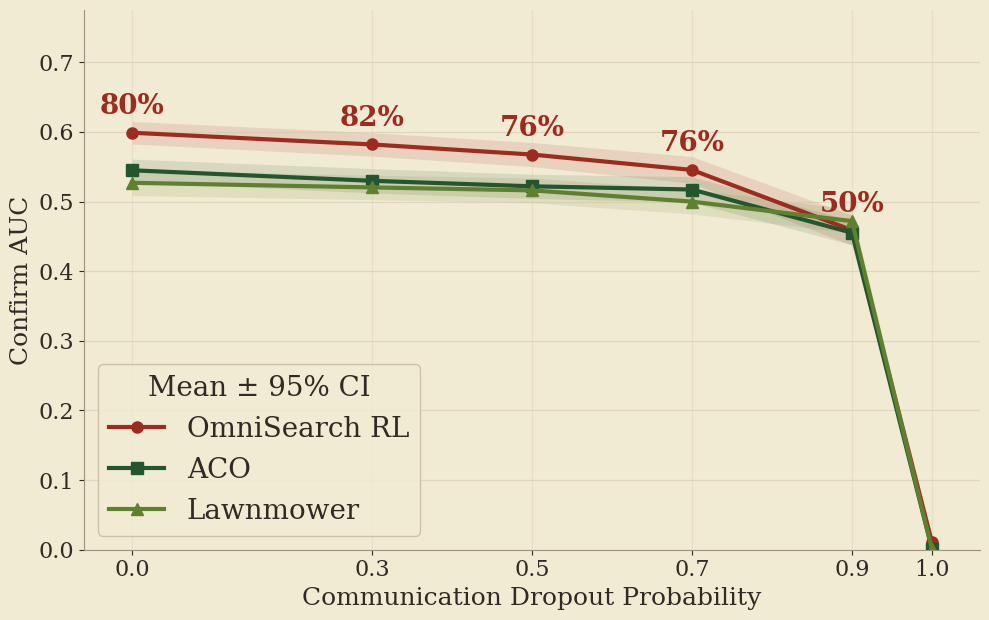

In [7]:
plot_df = metrics.copy()
if 'dropout_x' not in plot_df.columns:
    plot_df['dropout_x'] = plot_df.get('comms_dropout', float('nan'))
plot_df['dropout_x'] = pd.to_numeric(plot_df['dropout_x'], errors='coerce')
has_dropout_x = plot_df['dropout_x'].notna().all() and plot_df['dropout_x'].nunique() > 1


if has_dropout_x:
    fig, ax = plt.subplots(figsize=(10., 6.3), facecolor=plot.PAPER_BG)
    plot._plot_confirm_auc_curve(ax, plot_df, x_label='dropout_x', title='Confirm AUC vs Communication Dropout',x_title='Communication Dropout Probability')
    
else:
    plot_df = plot_df.reset_index(drop=True)
    fig, ax = plt.subplots(figsize=(max(15, len(plot_df) * 2.1), 6.3), facecolor=plot.PAPER_BG)
    plot._plot_metrics_bars(
            ax,
            plot_df,
            plot.AUC_METRIC_SPECS,
            title='Success And Time-Integrated Performance (AUC)',
            ylabel='Score',
            y_limit=(0.0, 1.35),
            label_digits=3,
            x_labels='strategy',
        )

fig.tight_layout()
plt.savefig("../outputs/figures/communication_dropout.png")
plt.show()